# Resumen del EDA de Yelp orientado a modelado

Esta notebook resume los hallazgos principales del EDA de Yelp y conserva la parte de modelado con **regresión lineal** y **random forest** como base para aprendizaje automático. La idea es tener una versión más corta, enfocada en las señales útiles para predicción.

In [5]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

def find_datasets_dir(folder_name: str = 'datasets') -> Path:
    start = Path.cwd()
    for d in (start, *start.parents):
        candidate = d / folder_name
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"No se encontró la carpeta '{folder_name}' desde {start}")


def read_json_sample(path, nrows=100_000):
    return pd.read_json(path, lines=True, nrows=nrows)

BASE_PATH = find_datasets_dir()
SAMPLE_ROWS = 100_000
print(f'Datasets encontrados en: {BASE_PATH}')
print(f'Versión resumida trabajando con una muestra de hasta {SAMPLE_ROWS:,} filas por archivo grande.')

Datasets encontrados en: c:\Users\usuario\Documents\yelp_dataset\datasets
Versión resumida trabajando con una muestra de hasta 100,000 filas por archivo grande.


In [7]:
print('Cargando datasets (muestra resumida)...')

df_user = read_json_sample(BASE_PATH / 'yelp_academic_dataset_user.json', nrows=SAMPLE_ROWS)
df_review = read_json_sample(BASE_PATH / 'yelp_academic_dataset_review.json', nrows=SAMPLE_ROWS)
df_tip = read_json_sample(BASE_PATH / 'yelp_academic_dataset_tip.json', nrows=SAMPLE_ROWS)
df_business = read_json_sample(BASE_PATH / 'yelp_academic_dataset_business.json', nrows=SAMPLE_ROWS)
df_checkin = read_json_sample(BASE_PATH / 'yelp_academic_dataset_checkin.json', nrows=SAMPLE_ROWS)
df_checkin['n_checkins'] = df_checkin['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1)

print('Carga finalizada.')

datasets_dict = {
    'Users (muestra)': df_user,
    'Reviews (muestra)': df_review,
    'Tips (muestra)': df_tip,
    'Check-ins (muestra)': df_checkin,
    'Business (muestra)': df_business,
}

summary_datasets = pd.DataFrame({
    'Dataset': list(datasets_dict.keys()),
    'Filas': [len(df) for df in datasets_dict.values()],
    'Columnas': [df.shape[1] for df in datasets_dict.values()],
    'NaN totales': [int(df.isna().sum().sum()) for df in datasets_dict.values()],
})

display(summary_datasets)

Cargando datasets (muestra resumida)...
Carga finalizada.


,Dataset,Filas,Columnas,NaN totales
0,Users (muestra),100000,22,0
1,Reviews (muestra),100000,9,0
2,Tips (muestra),100000,5,0
3,Check-ins (muestra),100000,3,0
4,Business (muestra),100000,14,24590


,Métrica,Valor
0,Total de usuarios,"100,000"
1,Antigüedad media (años),14.07
2,Reviews por usuario (media),92.63
3,Fans por usuario (media),7.48
4,Amigos por usuario (media),126.08
5,% usuarios elite (alguna vez),100.00 %
6,Estrellas promedio (media),3.8532


,Métrica,Valor
0,Total de reviews,"100,000"
1,Estrellas promedio,3.8429
2,Texto promedio (caracteres),548.4
3,Useful promedio,0.90
4,Funny promedio,0.26
5,Cool promedio,0.35


,Métrica,Valor
0,Total de negocios,"100,000"
1,Estrellas promedio,3.5972
2,Negocios abiertos (%),79.62 %
3,Categorías faltantes,69


,Métrica,Valor
0,Total de negocios con check-ins,"100,000"
1,Check-ins totales,"10,244,361"
2,Check-ins por negocio (media),102.44
3,Check-ins por negocio (mediana),20.00


C:\Users\usuario\AppData\Local\Temp\ipykernel_30028\2620090018.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=elite_counts.index, y=elite_counts.values, palette='viridis', ax=ax)


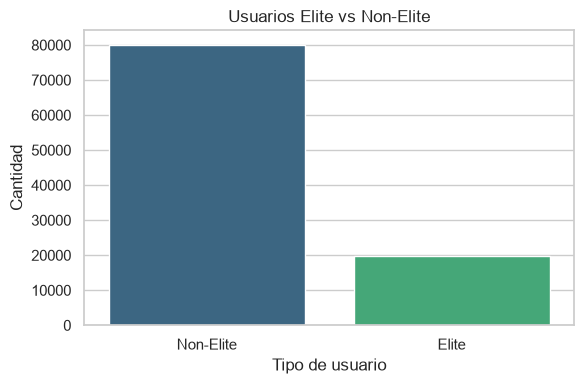

In [8]:
# Resumen EDA compacto para dejar listas las señales útiles para ML

df_user['elite'] = df_user['elite'].apply(lambda x: 'Elite' if isinstance(x, str) and len(x) > 0 else 'Non-Elite')
df_user['yelping_since'] = pd.to_datetime(df_user['yelping_since'])
df_user['years_active'] = (pd.Timestamp('2026-05-31') - df_user['yelping_since']).dt.days / 365.25
df_user['friend_count'] = df_user['friends'].apply(lambda x: 0 if (x == 'None' or x == '') else len(str(x).split(',')))
df_user['elite_years'] = df_user['elite'].apply(lambda x: 0 if (x == '' or pd.isna(x)) else len(str(x).split(',')))
compliment_cols = [c for c in df_user.columns if c.startswith('compliment_')]
df_user['total_compliments'] = df_user[compliment_cols].sum(axis=1)

user_summary = pd.DataFrame({
    'Métrica': [
        'Total de usuarios',
        'Antigüedad media (años)',
        'Reviews por usuario (media)',
        'Fans por usuario (media)',
        'Amigos por usuario (media)',
        '% usuarios elite (alguna vez)',
        'Estrellas promedio (media)',
    ],
    'Valor': [
        f"{len(df_user):,}",
        f"{df_user['years_active'].mean():.2f}",
        f"{df_user['review_count'].mean():.2f}",
        f"{df_user['fans'].mean():.2f}",
        f"{df_user['friend_count'].mean():.2f}",
        f"{(df_user['elite_years'] > 0).mean() * 100:.2f} %",
        f"{df_user['average_stars'].mean():.4f}",
    ]
})

review_summary = pd.DataFrame({
    'Métrica': [
        'Total de reviews',
        'Estrellas promedio',
        'Texto promedio (caracteres)',
        'Useful promedio',
        'Funny promedio',
        'Cool promedio',
    ],
    'Valor': [
        f"{len(df_review):,}",
        f"{df_review['stars'].mean():.4f}",
        f"{df_review['text'].str.len().mean():.1f}",
        f"{df_review['useful'].mean():.2f}",
        f"{df_review['funny'].mean():.2f}",
        f"{df_review['cool'].mean():.2f}",
    ]
})

business_summary = pd.DataFrame({
    'Métrica': [
        'Total de negocios',
        'Estrellas promedio',
        'Negocios abiertos (%)',
        'Categorías faltantes',
    ],
    'Valor': [
        f"{len(df_business):,}",
        f"{df_business['stars'].mean():.4f}",
        f"{df_business['is_open'].mean() * 100:.2f} %",
        f"{int(df_business['categories'].isna().sum()):,}",
    ]
})

checkins_per_business = df_checkin.set_index('business_id')['n_checkins']
checkin_summary = pd.DataFrame({
    'Métrica': [
        'Total de negocios con check-ins',
        'Check-ins totales',
        'Check-ins por negocio (media)',
        'Check-ins por negocio (mediana)',
    ],
    'Valor': [
        f"{len(df_checkin):,}",
        f"{checkins_per_business.sum():,}",
        f"{checkins_per_business.mean():.2f}",
        f"{checkins_per_business.median():.2f}",
    ]
})

display(user_summary)
display(review_summary)
display(business_summary)
display(checkin_summary)

fig, ax = plt.subplots(figsize=(6, 4))
elite_counts = df_user['elite'].value_counts()
sns.barplot(x=elite_counts.index, y=elite_counts.values, palette='viridis', ax=ax)
ax.set_title('Usuarios Elite vs Non-Elite')
ax.set_xlabel('Tipo de usuario')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Enfoque de modelado

Con el EDA resumido, el objetivo de modelado se centra en predecir el volumen de visitas del negocio (`n_checkins`). La variable objetivo es muy asimétrica, por eso se trabaja en escala `log1p` y luego se revierten las predicciones con `expm1`.

Las variables se mantienen deliberadamente simples e interpretables para comparar un baseline lineal contra un modelo no lineal como random forest.

In [9]:
# Dataset de modelado para predecir n_checkins

biz = df_business[['business_id', 'stars', 'review_count', 'state', 'city', 'is_open', 'attributes', 'hours']].copy()
biz = biz.set_index('business_id').join(checkins_per_business.rename('n_checkins'), how='inner')

def n_attributes(attr):
    if isinstance(attr, dict):
        return len(attr)
    return 0


def n_days_open(hours):
    if isinstance(hours, dict):
        return sum(1 for v in hours.values() if v and str(v).strip() != '0:0-0:0')
    return 0

biz['n_attributes'] = biz['attributes'].apply(n_attributes)
biz['n_days_open'] = biz['hours'].apply(n_days_open)

le_state = LabelEncoder()
biz['state_enc'] = le_state.fit_transform(biz['state'].fillna('Unknown'))
city_freq = biz['city'].value_counts()
biz['city_freq'] = biz['city'].map(city_freq).fillna(1)

feature_cols = ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
X = biz[feature_cols].fillna(0).astype(float)
y_log = np.log1p(biz['n_checkins'])
y_raw = biz['n_checkins']

print(f'Features: {feature_cols}')
print(f'Target n_checkins: media={y_raw.mean():.1f} | mediana={y_raw.median():.1f} | max={y_raw.max():,}')
print(f'log1p(n_checkins): media={y_log.mean():.3f} | std={y_log.std():.3f} | skew={y_log.skew():.3f}')

Features: ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
Target n_checkins: media=104.8 | mediana=20.0 | max=52,144
log1p(n_checkins): media=3.182 | std=1.625 | skew=0.446



Métricas comparativas:


,MAE (log),RMSE (log),R² (log),MAE (orig),RMSE (orig)
Regresión lineal,0.9747,1.2360,0.4180,12739369.8736,1207100916.8341
Random Forest,0.7697,0.9831,0.6318,58.4685,394.6972



Mejor modelo según R² en log: Random Forest


,Importancia
review_count,0.7864
n_attributes,0.0788
city_freq,0.0393
stars,0.0379
n_days_open,0.0272
state_enc,0.0251
is_open,0.0053


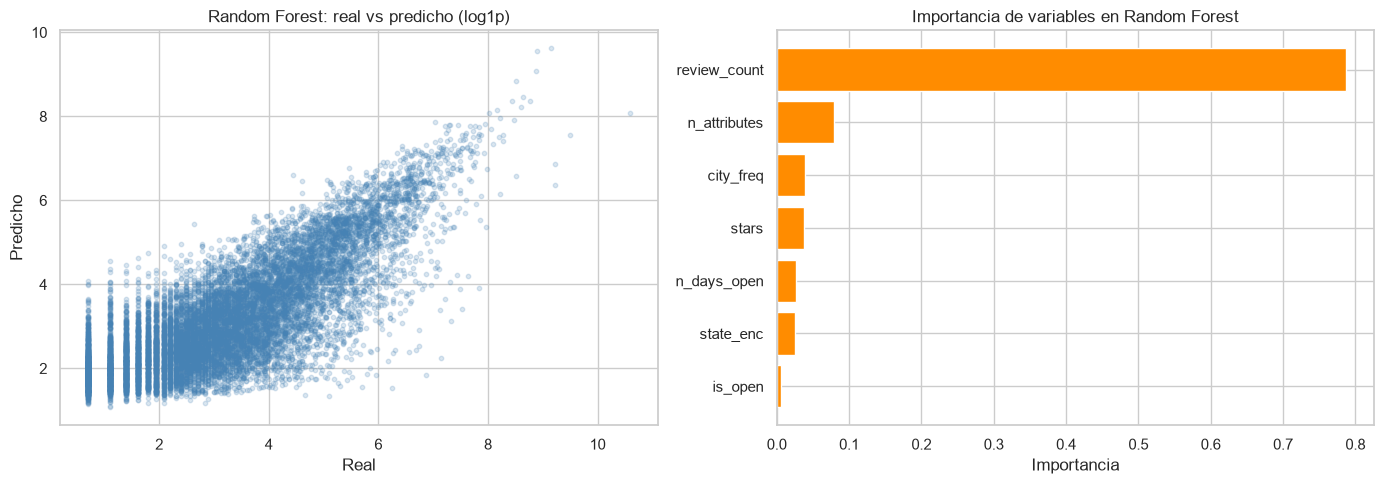

In [11]:
# Baseline lineal vs random forest

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_raw = np.expm1(y_test)

models = {
    'Regresión lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

results = {}
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    pred_raw = np.expm1(pred_log)
    fitted[name] = {'model': model, 'pred_log': pred_log, 'pred_raw': pred_raw}
    results[name] = {
        'MAE (log)': mean_absolute_error(y_test, pred_log),
        'RMSE (log)': np.sqrt(mean_squared_error(y_test, pred_log)),
        'R² (log)': r2_score(y_test, pred_log),
        'MAE (orig)': mean_absolute_error(y_test_raw, pred_raw),
        'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, pred_raw)),
    }

metrics = pd.DataFrame(results).T
print('\nMétricas comparativas:')
display(metrics.round(4))

best_name = metrics['R² (log)'].idxmax()
print(f'\nMejor modelo según R² en log: {best_name}')

rf = fitted['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.to_frame('Importancia'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, fitted['Random Forest']['pred_log'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Random Forest: real vs predicho (log1p)')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')

axes[1].barh(importances.index[::-1], importances.values[::-1], color='darkorange')
axes[1].set_title('Importancia de variables en Random Forest')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

## Cierre

Esta versión resumida deja el foco en dos cosas: los hallazgos del EDA que realmente ayudan a modelar y una comparación directa entre un baseline lineal y random forest. Si querés, el siguiente paso natural es extender esta notebook con un modelo de clasificación o con selección de variables más agresiva.